In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = yf.download("TCS.NS", start="2021-01-01", end="2024-01-01")
close = data['Close'].squeeze()

def calculate_rsi(prices, window=14):
    delta = prices.diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

data['RSI'] = calculate_rsi(close)
print(data['RSI'].tail(10))

[*********************100%***********************]  1 of 1 completed

Date
2023-12-15    82.928469
2023-12-18    82.310511
2023-12-19    75.143483
2023-12-20    73.914477
2023-12-21    73.186551
2023-12-22    74.704649
2023-12-26    70.625959
2023-12-27    67.761588
2023-12-28    65.852664
2023-12-29    64.415481
Name: RSI, dtype: float64


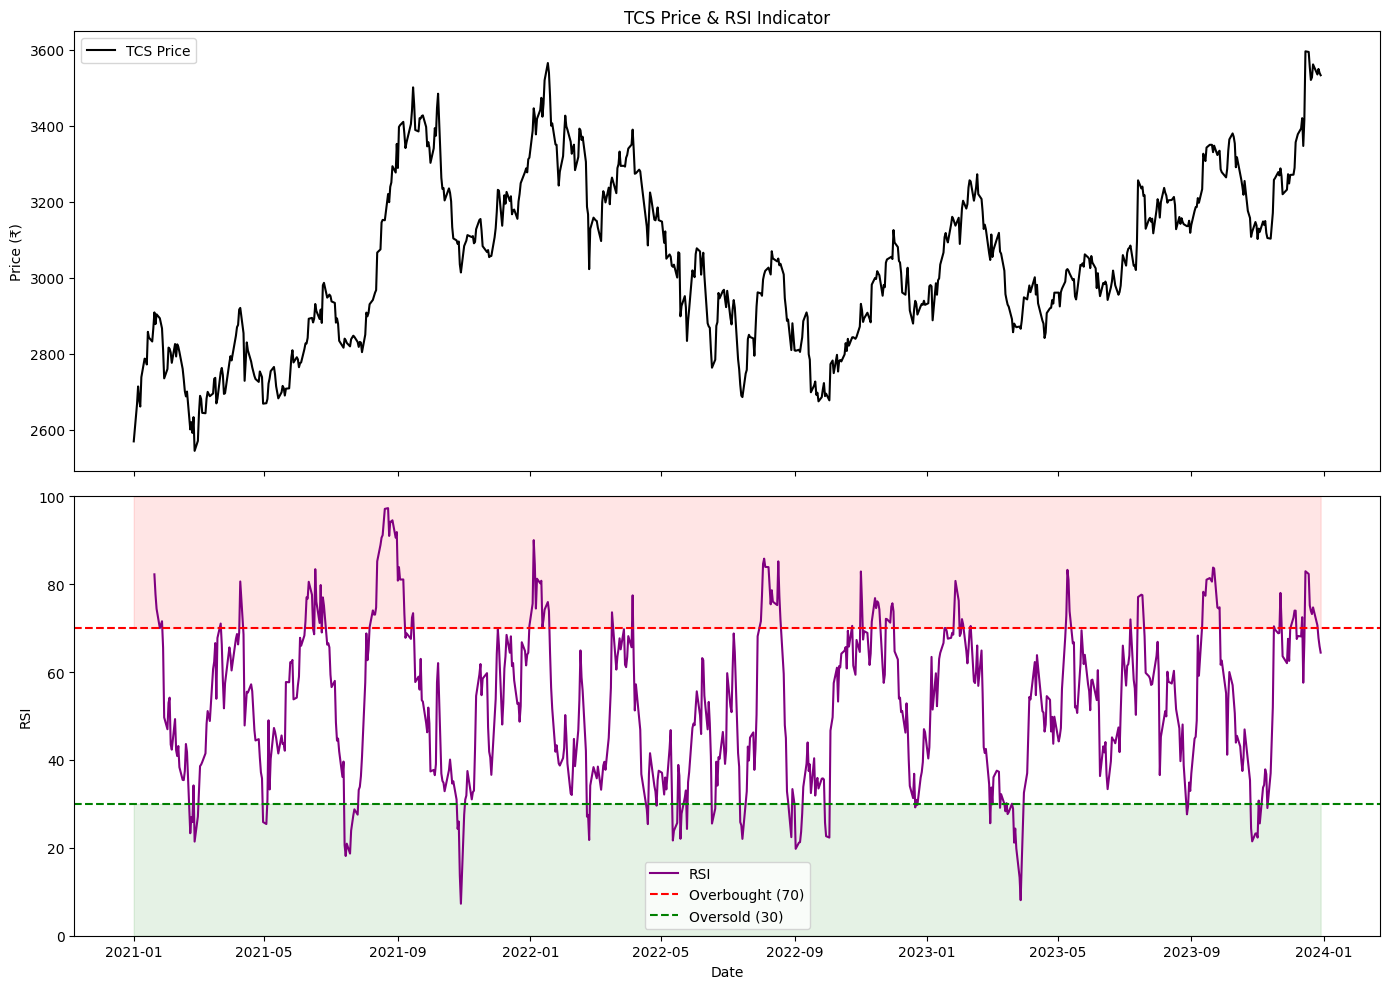

In [3]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

ax1.plot(close, label='TCS Price', color='black')
ax1.set_title('TCS Price & RSI Indicator')
ax1.set_ylabel('Price (₹)')
ax1.legend()

ax2.plot(data['RSI'], label='RSI', color='purple')
ax2.axhline(70, color='red', linestyle='--', label='Overbought (70)')
ax2.axhline(30, color='green', linestyle='--', label='Oversold (30)')
ax2.fill_between(data.index, 70, 100, alpha=0.1, color='red')
ax2.fill_between(data.index, 0, 30, alpha=0.1, color='green')
ax2.set_ylabel('RSI')
ax2.set_ylim(0, 100)
ax2.legend()

plt.xlabel('Date')
plt.tight_layout()
plt.show()

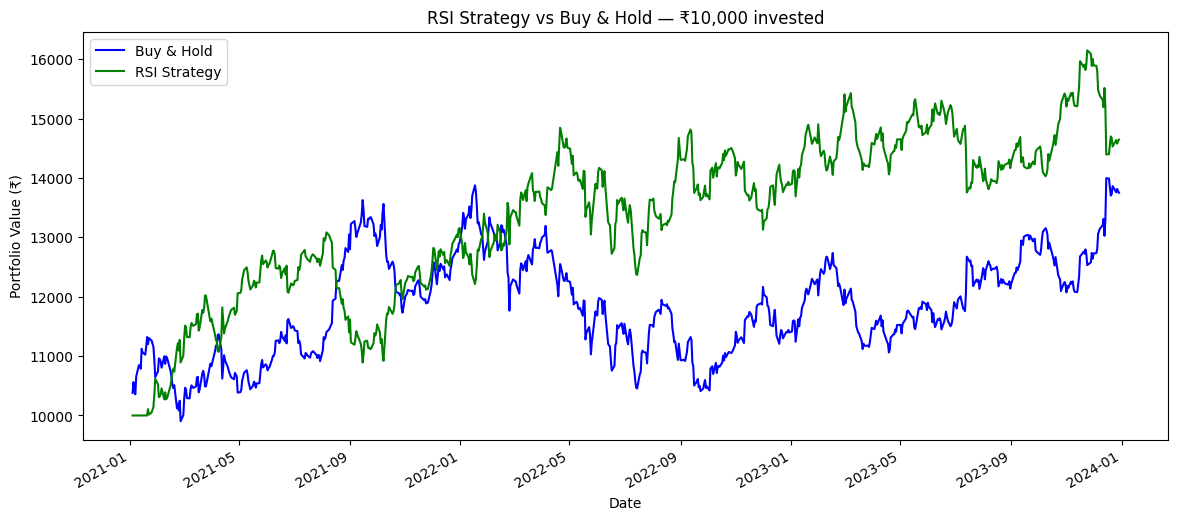

Buy & Hold final value:  ₹13751
RSI Strategy final value: ₹14645


In [4]:
data['Signal'] = 0
data.loc[data['RSI'] < 30, 'Signal'] = 1
data.loc[data['RSI'] > 70, 'Signal'] = -1

data['Position'] = data['Signal'].replace(0, np.nan).ffill().fillna(0)
data['Daily_Return'] = close.pct_change()
data['Strategy_Return'] = data['Daily_Return'] * data['Position'].shift(1)

data['Buy_Hold'] = (1 + data['Daily_Return']).cumprod() * 10000
data['Strategy'] = (1 + data['Strategy_Return']).cumprod() * 10000

plt.figure(figsize=(14, 6))
data['Buy_Hold'].plot(label='Buy & Hold', color='blue')
data['Strategy'].plot(label='RSI Strategy', color='green')
plt.title('RSI Strategy vs Buy & Hold — ₹10,000 invested')
plt.xlabel('Date')
plt.ylabel('Portfolio Value (₹)')
plt.legend()
plt.show()

print(f"Buy & Hold final value:  ₹{data['Buy_Hold'].iloc[-1]:.0f}")
print(f"RSI Strategy final value: ₹{data['Strategy'].iloc[-1]:.0f}")

## What I learned — Day 6: RSI Indicator

**What is RSI:**
RSI measures how stretched a stock's price is, like a rubber band.
It gives a value between 0 and 100.
Above 70 = overbought (stretched too high, likely to fall).
Below 30 = oversold (stretched too low, likely to bounce back).

**Why RSI beat buy and hold:**
Buy and hold stays in the stock every day — good and bad.
RSI strategy stepped out when TCS was overbought (RSI > 70),
avoiding some drops. Then bought back when oversold (RSI < 30).
Result: ₹14,645 vs ₹13,751 for buy and hold.

**RSI vs MA Crossover:**
MA Crossover is trend following — it joins a trend and rides it.
RSI is mean reversion — it bets the stock will snap back after 
going too far in one direction.
Two opposite philosophies — that's why one works where the other fails.